<img src="images/utfsm.png" alt="" width="150px" align="left"/>
<img src="images/utfsm.png" alt="" width="150px" align="right"/>
<br/>
<div align="center">
<h2>IPD-434 Seminario de Soft Computing</h2><br/>
<h1>Sistemas Difusos (Fuzzy Systems)</h1>
<br/><br/>
Dr. Nicolás Gálvez Ramírez<br/>
Dr. Patricio Olivares Roncagliolo<br/><br/>
Ingeniería Civil Telemática<br/>
Departamento de Eléctronica<br/>
Universidad Técnica Federico Santa María
</div>

Fuente: "Introduction to Soft Computing, Neuro-Fuzzy and Genetic Algorithms", Samir Roy, Udit Chakraborty

# Conjuntos difusos - Fuzzy Set

- Los conjuntos difusos corresponde a una **generalización** de los conjuntos clásicos.
- Resumen de la Teoría de Conjuntos clásica en el [Anexo 1](#anexo1).

# Membresía en un conjunto

## Función de membresía

- Considere un elemento $x$ y un conjunto $S$.
- Se define la membresía $x$ en $S$ como $\mu_{S}(x)$ de la siguiente manera:
$$
    \mu_{S}(x) = \begin{cases}
      1, & \text{if } x \in S \\
      0, & \text{if } x \notin S
    \end{cases}
$$
- Ej: 
$$A = \{\text{piedra}, \text{papel}, \text{papel}\}$$

$$\mu_{A}(\text{piedra}) = 1$$
$$\mu_{A}(\text{spock}) = 0$$


Considere los siguientes conjuntos

$$ U = \{\text{72 años }, \text{63 años }, \text{41 años }, \text{38 años }, \text{13 años }, \text{15 años }, \text{52 años }\} $$
$$ A = \{ x \mid x \text{ es anciano } \} $$


Comprobando algunos elementos del conjunto $U$ en la función de membresía $\mu_{A}(x)$

- 72 años se pede considerar anciano con seguridad, por lo tanto 
$$ \mu_{A}(\text{72 años}) = 1 $$
<br>
- 13 años se puede considerar que no es anciano con seguridad, por lo tanto 
$$ \mu_{A}(\text{13 años}) = 0 $$

Sin embargo, ¿qué ocurre en otros casos?

$$ \mu_{A}(\text{63 años}) = \text{ ?}$$
$$ \mu_{A}(\text{41 años}) = \text{ ?}$$
$$ \mu_{A}(\text{52 años}) = \text{ ?}$$

Depende de cómo se define la **pertenencia** al conjunto anciano, lo cual no está **claramente** definido. Para estos casos, es conveniente expresar esta incertidumbre en la función de membresía.

Consideremos la siguiente función de membresía para el conjunto $A$:


$$
    \mu_{A}(x) = \begin{cases}
      0, & \text{if } x < 30 \\
      \frac{x-30}{40}, & \text{if } 30 \leq x < 70 \\
      1, & \text{if } x \geq 70 \\
    \end{cases}
$$

Donde $x$ representa la edad. Aplicando dicha función a los elementos en $U$:

$$ \mu_{A}(\text{72 años}) = 1.0 $$
$$ \mu_{A}(\text{63 años}) = 0.825 $$
$$ \mu_{A}(\text{41 años}) = 0.275 $$
$$ \mu_{A}(\text{38 años}) = 0.2 $$
$$ \mu_{A}(\text{13 años}) = 0.0 $$
$$ \mu_{A}(\text{15 años}) = 0.0 $$
$$ \mu_{A}(\text{52 años}) = 0.55 $$

A continuación se muestra un gráfico de la función $\mu_{A}(x)$

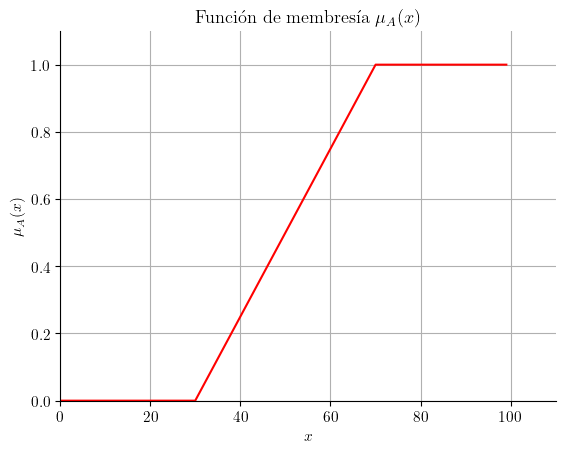

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[0:30]*0
y2 = (x[30:70]-30)/40
y3 = x[70:]*0 + 1
y = np.concatenate([y1, y2, y3])

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía $\mu_{A}(x)$')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{A}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r')
plt.grid()
plt.show()

Para enumerar los elementos pertenecientes al conjunto $A$, se debe incluir el valor de su función de membresía.

$$ B = \{(\text{72 años}, 1.0), (\text{63 años}, 0.825), (\text{41 años}, 0.275), (\text{38 años}, 0.2), (\text{52 años}, 0.55) \} $$

- *No se agregan aquellos elementos con valor 0*

# Conjuntos difusos (Fuzzy sets)

- Agregan el concepto de **incerteza e imprecisión** a los conjuntos tradicionales.
- **Definición Formal**: Se define $F$ como conjunto difuso dentro de un conjunto universo $U$ como la colleción de pares ordenados $(x, \mu_{F}(x)$ donde $x \in U$ y $\forall x \in U, 0.0 \leq \mu_{F}(x) \leq 1.0$.

$$ F = \{ (x, \mu_{F}(x)) \mid x \in U, 0.0 \leq \mu_{F}(x) \leq 1.0 \} $$
- Cada par $(x, \mu_{F}(x))$ se conoce como **singleton**.

# Notación de conjuntos difusos

- Además de enumerar singletons, los conjuntos difusos también se expresan con la siguiente notación

$$ F = \sum_{x \in U} \frac{\mu_{F}(x)}{x}$$

donde $\sum$ representa unión de singletons, no suma aritmética.

- En conjuntos continuos, se reemplaza el símbolo de sumatoria con la integral

$$ F = \int_{U} \frac{\mu_{F}(x)}{x}$$

# Características de conjuntos difusos

- **Normalidad**: $F$ es normal si al menos un elemento pertenece completamente a $F$ 

$$\exists x \, | \, \mu_{F}(x) = 1.0$$

- **Altura**: 

$$ \text{height}(F) = \max_{x \in U} \mu_{F}(x)$$

$F$ es normal si $\text{height}(F)=1.0$.

- **Soporte**:

$$\text{supp}(F) = \{x \mid x \in U, \mu_{F}(x)>0\}$$

- **Núcleo**: 

$$ \text{core}(F)=\{ x \mid x \in U, \mu_{F}(x)=1 \}$$
$$ \text{core}(F) \subseteq \text{supp}(F)$$

*El soporte y el núcleo corresponden a conjuntos tradicionales (clásicos)*

- **Cardinalidad**: Suma de los valores de membresía

$$ |F| = \sum_{x \in U}\mu_{F}(x)$$

donde $\sum$ sí representa la suma aritmética de los valores $\mu_{F}(x)$

# Funciones de membresía

- Una función de membresía puede ser cualquier función del tipo 

$$\mu_{F} \mid U \rightarrow [0,1]$$

## Funciones de membresía frecuentes

### Función triangular

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      \frac{x-a}{m-a}, & \text{if } a \leq x < m \\
      \frac{b-x}{b-m}, & \text{if } m \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

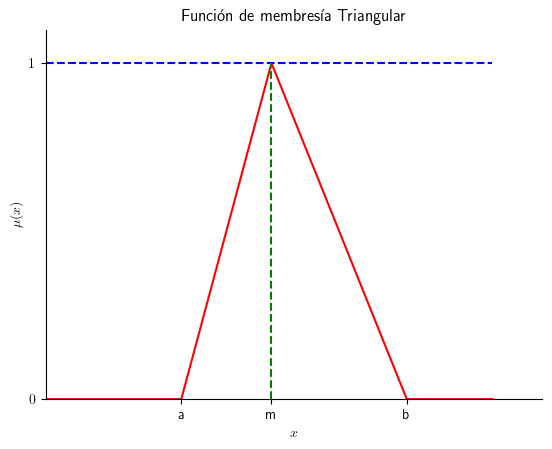

In [69]:
import matplotlib.pyplot as plt
import numpy as np

a = 30
m = 50
b = 80

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = (x[a:m]-a)/(m-a)
y3 = (b-x[m:b])/(b-m)
y4 = x[b:]*0 
y = np.concatenate([y1, y2, y3, y4])
line_1 = np.ones(len(x))
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m


fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Triangular')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([a,m,b])
ax.set_xticklabels(['a', 'm', 'b'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--')
plt.show()

### Función trapezoidal

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      \frac{x-a}{m-a}, & \text{if } a \leq x < m \\
      1, & \text{if } m \leq x < n \\
      \frac{b-x}{b-n}, & \text{if } n \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

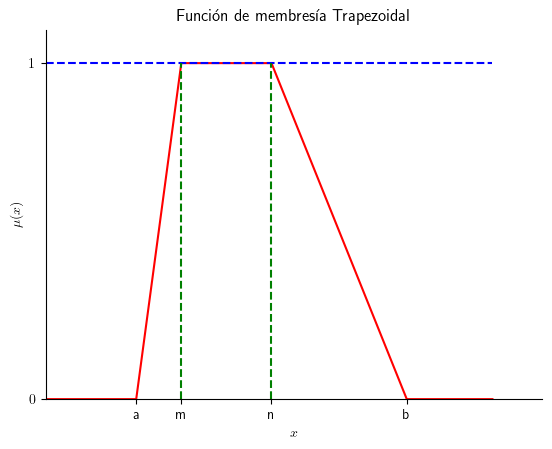

In [68]:
import matplotlib.pyplot as plt
import numpy as np

a = 20
m = 30
n = 50
b = 80

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = (x[a:m]-a)/(m-a)
y3 = np.ones(n-m)
y4 = (b-x[n:b])/(b-n)
y5 = x[b:]*0 
y = np.concatenate([y1, y2, y3, y4, y5])
line_1 = np.ones(len(x))
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m
y_n = np.linspace(0,1,len(x))
line_n = np.ones(len(x))*n


fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Trapezoidal')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([a, m, n, b])
ax.set_xticklabels(['a', 'm', 'n', 'b'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--', line_n, y_n, 'g--')
plt.show()

### Función Gaussiana

$$ \mu(x) = e^{-k(x-m)^2} \text{ where } k > 0 $$

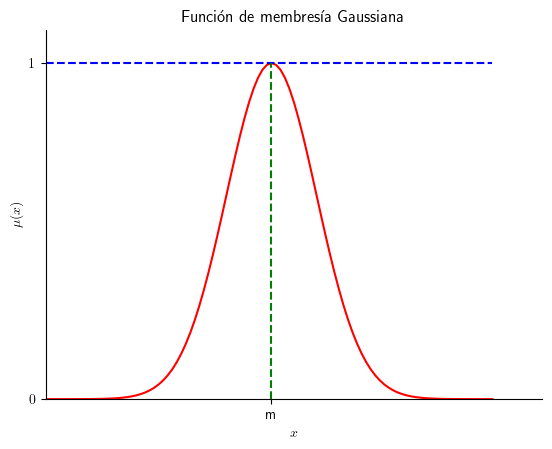

In [66]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = np.exp(-k*(x-m)**2)
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Gaussiana')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([m])
ax.set_xticklabels(['m'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--')
plt.show()

### Función-S

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      2 \Bigl( \frac{x-a}{b-a} \Bigr)^2, & \text{if } a \leq x < m \\
      1 - 2 \Bigl( \frac{x-b}{b-a} \Bigr)^2, & \text{if } m \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

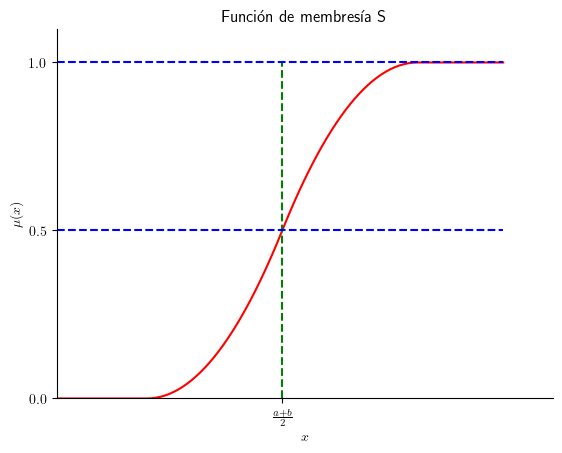

In [2]:
import matplotlib.pyplot as plt
import numpy as np

a = 20
b = 80
m = int((a+b)/2)
n = 50

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = 2*(((x[a:m]-a)/(b-a))**2)
y3 = 1-2*(((x[m:b]-b)/(b-a))**2)
y4 = np.ones(len(x[b:]))
y = np.concatenate([y1, y2, y3, y4])
line_1 = np.ones(len(x))
line_05 = np.ones(len(x))/2
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m
y_n = np.linspace(0,1,len(x))
line_n = np.ones(len(x))*n

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía S')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([m])
ax.set_xticklabels([r'$\frac{a+b}{2}$'])
ax.set_yticks([0.0, 0.5, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', line_m, y_m, 'g--', x, line_1, 'b--', line_05, 'b--')
plt.show()

## Transformaciones sobre conjuntos difusos

Existen algunas transformaciones útiles que pueden ser aplicadas sobre conjuntos difusos.

### Normalización

Permite convertir un conjunto difuso subnormal a un conjunto normal.

$$ \text{NORM}(F,x) = \frac{\mu_{F}(x)}{\text{height}(F)}$$

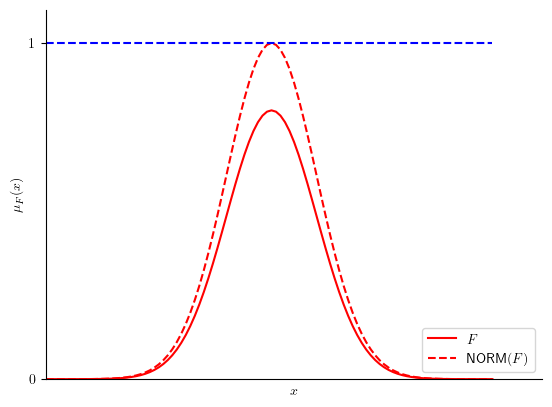

In [71]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005
a = 0.8

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = a*np.exp(-k*(x-m)**2)
y_norm = y/(np.max(y))
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{F}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([0.0, 1.0])
ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r',x, y_norm, 'r--', x, line_1, 'b--')

plt.legend([r'$F$', r'NORM$(F)$'])
plt.show()

### Dilatación

Operación que permite dilatar (aplanar) la función de membresía.

$$ \text{DIL}(F,x)=\bigl(\mu_{F}(x)\bigr)^{\frac{1}{2}} $$

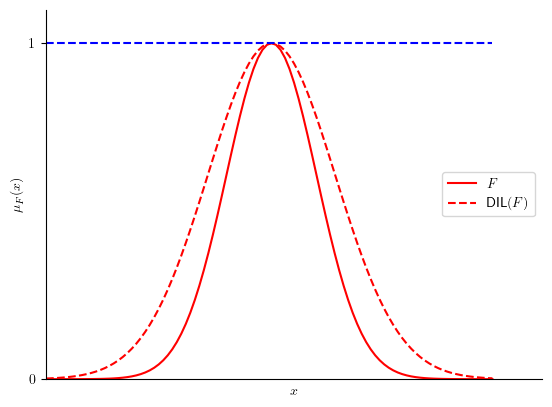

In [30]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005
a = 1.0

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = a*np.exp(-k*(x-m)**2)
y_dil = np.sqrt(y)
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{F}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([0.0, 1.0])
ax.set_xticks([])
ax.set_xticklabels([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r',x, y_dil, 'r--', x, line_1, 'b--')

plt.legend([r'$F$', r'DIL$(F)$'])
plt.show()

### Concentración

Operación que produce el efecto contrario a la dilatación.

$$ \text{CON}(F,x)=\bigl(\mu_{F}(x)\bigr)^2 $$

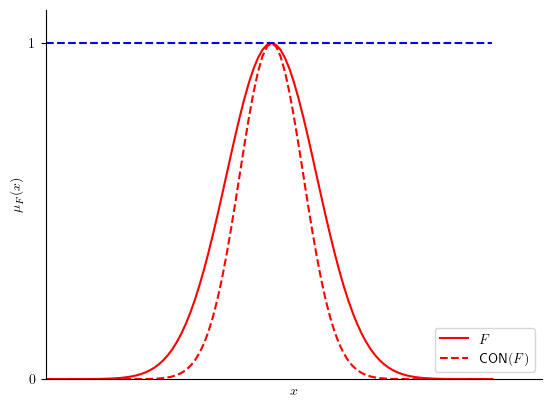

In [31]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005
a = 1.0

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = a*np.exp(-k*(x-m)**2)
y_con = y**2
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{F}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([0.0, 1.0])
ax.set_xticks([])
ax.set_xticklabels([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r',x, y_con, 'r--', x, line_1, 'b--')

plt.legend([r'$F$', r'CON$(F)$'])
plt.show()

### Intensificación de contraste

Reduce los valores de membresía menores de 0.5 y potencia valores mayores que 0.5.

$$
    \text{INF}(F,x) = \begin{cases}
      2\bigl(\mu_{F}(x)\bigr)^2, & \text{if } 0 \leq \mu_{F}(x) \leq 0.5 \\
      1-2\bigl(1-\mu_{F}(x)\bigr)^2, & \text{otherwise } 
    \end{cases}
$$

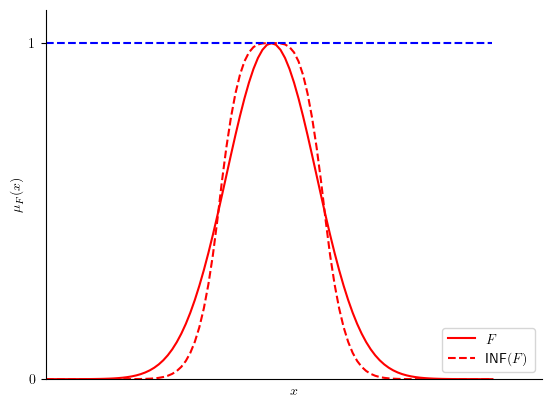

In [32]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005
a = 1.0

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = a*np.exp(-k*(x-m)**2)
y_inf = np.where(y<=0.5, 2*(y**2), 1-2*((1-y)**2))
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{F}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([0.0, 1.0])
ax.set_xticks([])
ax.set_xticklabels([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r',x, y_inf, 'r--', x, line_1, 'b--')

plt.legend([r'$F$', r'INF$(F)$'])
plt.show()

### Difusión (fuzzification)

Produce el efecto contrario a la intensificación de contraste. Valores menores de 0.5 son potenciados y valores mayores a 0.5 son reducidos.

$$
    \text{FUZZ}(F,x) = \begin{cases}
      \bigl(\frac{\mu_{F}(x)}{2}\bigr)^{\frac{1}{2}}, & \text{if } 0 \leq \mu_{F}(x) \leq 0.5 \\
      1-\bigl(\frac{1-\mu_{F}(x)}{2}\bigr)^{\frac{1}{2}}, & \text{otherwise } 
    \end{cases}
$$

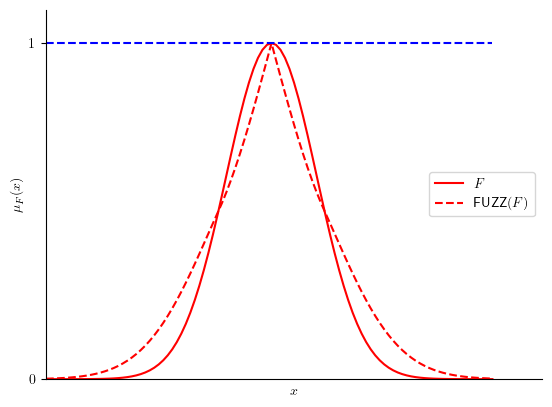

In [29]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005
a = 1.0

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = a*np.exp(-k*(x-m)**2)
y_fuzz = np.where(y<=0.5, np.sqrt(y/2), 1-np.sqrt((1-y)/2))
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{F}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([0.0, 1.0])
ax.set_xticks([])
ax.set_xticklabels([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r',x, y_fuzz, 'r--', x, line_1, 'b--')

plt.legend([r'$F$', r'FUZZ$(F)$'])
plt.show()

# Variables lingüísticas

- Descripciones lingüísticas pueden en ocasiones ser traducidas a transformaciones sobre funciones de membresía.
- Ej: Gráfico para función de membresía `alto` y `muy alto`.

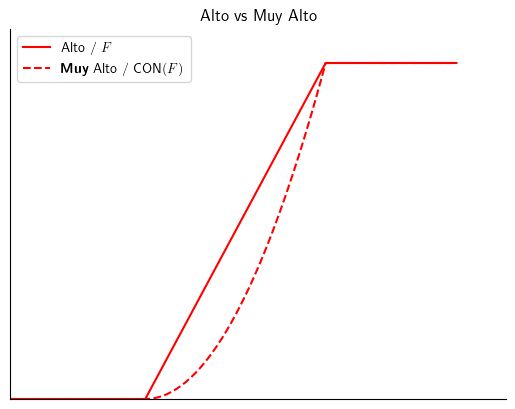

In [40]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[0:30]*0
y2 = (x[30:70]-30)/40
y3 = x[70:]*0 + 1
y = np.concatenate([y1, y2, y3])
y_vtall = y**2

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Alto vs Muy Alto')
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_xticks([])
ax.set_xticklabels([])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, y_vtall, 'r--')
plt.legend([r'Alto / $F$', r'\textbf{Muy} Alto / CON$(F)$'])
plt.grid()
plt.show()

# Operaciones en conjuntos difusos

Una gran cantidad de operaciones de conjuntos clásicas pueden ser aplicadas directamente sobre conjuntos difusos.

### Unión ($P \cup Q$)

$$ \mu_{P \cup Q}(x) = \max\{\mu_{P}(x), \mu_{Q}(x)\}, \forall x \in U$$

### Intersección ($P \cap Q$)

$$ \mu_{P \cap Q}(x) = \min\{\mu_{P}(x), \mu_{Q}(x)\}, \forall x \in U$$

### Complemento ($\bar{P}$)

$$ \mu_{\bar{P}}(x) = 1 - \mu_{P}(x), \forall x \in U$$

### Igualdad ($P=Q$)

$$P=Q \Leftrightarrow \forall x \in U, \mu_{P}(x)=\mu_{Q}(x)$$

### Inclusión ($P \subseteq Q$)

$$P \subseteq Q \Leftrightarrow \forall x \in U, \mu_{P}(x)\leq\mu_{Q}(x)$$

### Producto ($P \cdot Q$)

$$\mu_{P \cdot Q}(x) = \{ \mu_{P}(x) \times \mu_{Q}(x) \}, \forall x \in U$$

### Diferencia ($P - Q$)

$$ P - Q = P \cap \bar{Q}$$

### Diferencia Simétrica ($P \oplus Q$)

$$ P \oplus Q = (P \cap \bar{Q}) \cup (\bar{P} \cap Q)$$

# Relaciones entre conjuntos difusos

- Así como existen las relaciones entre conjuntos tradicionales, también es posible definir relaciones entre conjuntos difusos. Recordatorios sobre relaciones entre conjuntos tradicionales en el [Anexo 2](#anexo2).

## Producto Cartesiano difuso ($A \times B$)

Sea $A$ y $B$ dos conjuntos difusos sobre dos conjuntos de tradicionales $X$ e $Y$, se denota el producto cartesiano entre $A$ y $B$ como $A \times B \subseteq X \in Y$ donde

$$ \mu_{A \times B}(a,b) = \min\{ \mu_{A}(a), \mu_{B}(b) \} \forall a \in X, \forall b \in Y\}$$

### Ejemplo

Considere los conjuntos $X=\{ m, n \}$ e $Y = \{ p, q, r \}$, y los conjuntos difusos $A$ y $B$ definidos sobre ellos como 

$$ A = \frac{0.3}{m} + \frac{0.7}{n}$$

$$ B = \frac{0.5}{p} + \frac{0.1}{q} + \frac{0.8}{r}$$

La función de membresía del producto cartesiano $A \times B$ para algunos de sus pares de elementoses son los siguientes:

$$\mu_{A \times B} (m, p) = \min\{ 0.3, 0.5 \} = 0.3$$
$$\mu_{A \times B} (m, q) = \min\{ 0.3, 0.1 \} = 0.1$$

La matriz de relación de dicho producto cartesiano sería la siguiente

$$ T_{A \times B} = \begin{bmatrix}
0.3 & 0.1 & 0.3\\
0.5 & 0.1 & 0.7
\end{bmatrix}$$

## Relaciones difusas

Se define una relación $R$ entre dos conjuntos difusos $A$ y $B$ como un **subconjunto** del producto cartesiano $R \subseteq A \times B$

### Ejemplo

Considerando los conjuntos definidos en el ejemplo anterior de producto cartesiano sobre conjuntos difusos, la siguiente matriz de relación define una relación **válida** entre los conjuntos difusos $A$ y $B$.

$$ T_{R} = \begin{bmatrix}
0.2 & 0.1 & 0.1\\
0.3 & 0.0 & 0.5
\end{bmatrix}$$

## Operaciones en relaciones difusas

- La mayoría de operaciones sobre relaciones en conjuntos tradicionales son válidas sobre conjuntos difusos.
- Entre estas operaciones se encuentra la *Unión, Intersección, Complemento e Inclusión (subconjunto)*, definidas en el [Anexo2](#anexo2).
- También existen modificaciones o generalizaciones de operaciones definidas en los conjuntos tradicionales.

### Composición max-min

- Corresponde a la generalización de la composición de conjuntos tradicionales para conjuntos difusos.
- Considere los conjuntos tradicionales $A$, $B$ y $C$ y los relaciones difusas $R$ y $S$ sobre $A \times B$ y $B \times C$ respectivamente, se define la composición max-min de $R$ en $S$ (denotado como $R \circ S$) como la relación sobre $A \times C$ tal que:

$$ (R \circ S)(x,z) = \max_{y \in B} \{ \min \{ R(x,y), S(y,z) \} \} $$

**Ejemplo**

Considere los grupos $A=\{ a, b, c \}$, $B = \{ x, y \}$ y $C=\{ p, q, r \}$ y las siguientes relaciones $R$ y $S$ sobre $A \times B$ y $B \times C$:

$$ T_{R} = \begin{bmatrix}
0.3 & 0.7 \\
0.9 & 0.4 \\
0.2 & 0.5
\end{bmatrix}$$

$$ T_{S} = \begin{bmatrix}
0.4 & 0.1 & 0.8 \\
0.3 & 0.7 & 0.6
\end{bmatrix}$$

Calculando la *composición min-max* para algunos elementos

\begin{equation}
\begin{split}
(R \circ S)(a, p) &= \max_{i \in B} \{ \min \{ R(a,i), S(i,p) \} \} \\
                  &= \max\{ \min(R(a,x), S(x,p)), \min(R(a,y), S(y, p)) \} \\
                  &= \max\{ \min(0.3, 0.4), \min(0.7, 0.3) \} \\
                  &= \max\{ 0.3, 0.3 \} \\
                  &= 0.3
\end{split}
\end{equation}


\begin{equation}
\begin{split}
(R \circ S)(a, q) &= \max_{i \in B} \{ \min \{ R(a,i), S(i,q) \} \} \\
                  &= \max\{ \min(R(a,x), S(x,q)), \min(R(a,y), S(y, q)) \} \\
                  &= \max\{ \min(0.3, 0.1), \min(0.7, 0.7) \} \\
                  &= \max\{ 0.1, 0.7 \} \\
                  &= 0.7
\end{split}
\end{equation}

Representado la relación completa a través de su matriz de relación:

$$ T_{R \circ S} = \begin{bmatrix}
0.3 & 0.7 & 0.6 \\
0.4 & 0.7 & 0.8 \\
0.3 & 0.5 & 0.5
\end{bmatrix}$$

# Principio de extensión

- Considere la función $f: U_1 \times U_2 \times \cdots U_n \rightarrow V$ donde los conjuntos $U_i$ y $V$ corresponden conjuntos tradicionales. Si existe un elemento $v \in V$ tal que $f(u_1, u_2, \ldots, u_n) = v$ se dice que
    - $v$ es la **imagen** del punto $(u_1, u_2, \ldots, u_n)$, definido por $f(u_1, u_2, \ldots, u_n) = v$
    - $(u_1, u_2, \ldots, u_n)$ es la **pre-imagen** de $v$, definido por $(u_1, u_2, \ldots, u_n) = f^{-1}(v)$
- Luego, considere los conjuntos difusos $A_1, A_2, \ldots, A_n$ en los conjuntos universos $U_1, U_2, \ldots, U_n$ respectivamente. Dada la función $f$ definida anteriormente, es posible construir un conjunto difuso $B$ en $V$ de la siguiente manera:
    - Para cada $v \in V$ 
    $$
    \mu_{B}(v) = \begin{cases}
      0, & \text{if } f^{-1}(v) \neq \phi \\
     \max \{ \min\{\mu_{A_1})(u_1), \mu_{A_2}(u_2), \ldots, \mu_{A_n}(u_n)\} \}, & \text{otherwise}
    \end{cases}
    $$

# Lógica Difusa (Fuzzy Logic)

A diferencia de lo que ocurre en la lógica de conjuntos tradicional ([Anexo 3](#anexo3)), en lógica difusa se admite la posibilidad de diferentes valores de verdad o falsedad entre la verdad absoluta y la falsedad absoluta.

## Valores de verdad difusos

Mientras los valores de verdad para conjuntos tradicionales solo pueden ser verdadero/$1$ o falso/$0$, los valores de verdad difusos incluyen múltiples valores entre $0$ y $1$ incluyendo estos últimos. 

**Ejemplos**
Algunos valores lingüísticos pueden ser asociados a valores numéricos como se muestra en la tabla siguiente


| Valor lingüistico        | Valores   |
|--------------------------|-----------|
| Completamente Falso      | 0.0       | 
| Parcialmente Falso       | 0.25      |
| Ni Verdadero ni Falso    | 0.5       |
| Verdadero y Falso        | 0.5       |
| Parcialmente Verdadero   | 0.75      |
| Completamente Verdadero  | 1.0       |

## Proposiciones difusas

Son aquellas proposiciones que pueden tener valores de verdad difusos.
Sea $p$ una proposición difusa, se define $\tau(p)$ como su valor de verdad difuso, donde $0 \leq \tau(p) \leq$

**Ejemplos**

| Proposición                      | Valor lingüístico             | Valor numérico |
|----------------------------------|-------------------------------|----------------|
| $\sqrt 2$ es un número racional  | Completamente Falso            | 0.0            | 
| Él es millonario                 | Parcialmente Falso            | 0.4            |
| La Tierra es Redonda             | Casi completamente Verdadero  | 0.97           |
| El único número primo y par es 2 | Completamente Verdadero       | 1.0            |

## Operaciones de lógica difusa

Operaciones básicas de lógica de conjuntos tradicional tiene su equivalente difuso según aparece en la siguiente tabla

|Operación                     |             | Uso  |                                                          |
|------------------------------|-------------|------|----------------------------------------------------------|
|Disyunción                    |$+$          |$P+Q$ | $\tau(P+Q) = \max\{ \tau(P), \tau(Q) \}$                 |


|Operación       |Símbolo       |Uso               |Definición                                               |
|----------------|--------------|------------------|---------------------------------------------------------|
| Disyunción      | $+$           | $ P+Q $             | $\tau(P+Q) = \max\{ \tau(P), \tau(Q) \}$                 |
| Conjunción      | $ \bullet $     | $ P \bullet Q$     | $\tau(P\bullet Q) = \min\{ \tau(P), \tau(Q) \}$          | 
| Negación        | $ \neg $        | $\neg P$          | $\tau(\neg P) = 1 - \tau(P)$                             |
| Implica         | $ \rightarrow $ | $P \rightarrow Q$ | $\tau(P \rightarrow Q) = \max\{ 1 - \tau(P), \tau(Q) \}$ |

## Valores de verdad difusos

- Los valores de verdad en lógica difusa equivalen a los valores de membresía de un elemento a un conjunto difuso.
- Considere el conjunto $F$ sobre el universo $U$, y un elemento $x \in U$. El valor de verdad de la proposición $ p = \text{'x es un miembro de F'}$ corresponde simplemente al valor de membresía de $x$ en $F$. Es decir $\tau(p) = \mu_{F}(x)$.
- Debido a esto último, la lógica difusa y la teoría de conjuntos difusos son sistemas isomórficos.

## Valores de verdad difusos y variables lingüísticas

- Es posible encontrar el valor de verdad $\tau(s)$ de una proposición difusa $s=\text{'x es P'}$, donde $P$ es un valor difuso de una variable lingüística $L$, de la siguiente manera:
    1. Evaluar $L$ por $x$
    2. Encontrar la membresía de $L(x)$ en $P$.
    3. $\tau(s) = \mu_{P}(L(x))$

<div id="anexo1" />

# Anexo 1: Teoría de conjuntos clásica

## Definición de conjunto

Colección de elementos no repetidos y sin un orden determinado.

**Ejemplo** (notaciones de conjuntos)
\begin{equation}
\begin{split}
    A &= \{ \text{piedra}, \text{papel}, \text{tijera} \} & \rightarrow \text{  Enumeración  }\\
    B &= \{ n \in \mathbb{Z} \mid n \text{ es par } \} & \rightarrow \text{  Descripción  } 
\end{split}
\end{equation}

## Cardinalidad

Número de elementos presente en un conjunto

**Ejemplo**
\begin{equation}
\lvert A \rvert = 3; \lvert B \rvert = \infty
\end{equation}

## Conjunto nulo/vacío ($phi$)

Conjunto sin elementos
\begin{equation}
\lvert \phi \rvert = 0
\end{equation}

## Conjunto Universo ($U$)

Conjunto de todos los elementos posibles en un contexto

## Subconjunto ($\subseteq$)

Se define un conjunto $T$ como subconjunto ($\subseteq$) de un conjunto $S$ si $\forall x, x \in T \Rightarrow x \in S$ 

## Igualda de conjuntos ($=$)

Dos conjuntos $T$ y $S$ son iguales si $T \subseteq S$ y $S \subseteq T$

## Conjunto Potencia

Conjunto de todos los subconjuntos a partir de un conjunto inicial

**Ejemplo**

\begin{equation}
\begin{split}
    P(A) &= \{ \phi, \{ \text{piedra} \}, \{ \text{papel} \}, \{ \text{tijera} \}, \{ \text{piedra}, \text{papel} \}, \{ \text{piedra}, \text{tijera} \}, \{ \text{papel}, \text{tijera} \}, \{ \text{piedra}, \text{papel}, \text{tijera} \} \}\\
\end{split}
\end{equation}

## Operaciones de conjuntos

Dados los conjuntos genéricos $P$ y $Q$, se definen las siguientes operaciones:

### Unión ($\cup$)

$$ P \cup Q = \{ x \mid x \in P \text{ or } x \in Q \}$$

### Intersección ($\cap$)

$$ P \cap Q =  \{ x \mid x \in P \text{ and } x \in Q  \}$$

### Complemento ($\bar{P}$)

$$ \overline{P} = \{ x \mid x \notin P \} $$

### Diferencia entre conjuntos ($-$)

\begin{equation}
\begin{split}
     P - Q &= \{ x \mid x \in P \text{ and } x \notin Q \} \\
     P - Q &= P \cap \bar{Q}
\end{split}
\end{equation}

### Diferencia Simétrica ($\oplus$)

\begin{equation}
\begin{split}
     P \oplus Q &= \{ x \mid (x \in P \text{ and } x \notin Q) \text{ or } (x \in Q \text{ and } x \notin P) \} \\
     P \oplus Q &= (P-Q) \cup (Q - P) \\
     P \oplus Q &= (P \cap \bar{Q}) \cup (\bar{P} \cap Q) \\
\end{split}
\end{equation}

### Producto cartesiano ($\times$)

$$ P \times Q = \{ (x,y) \mid x\in P \text{ and } y \in Q \}$$

## Propiedades de conjuntos

### Idempotencia

\begin{equation}
\begin{split}
    A \cup A &= A \\
    A \cap A &= A
\end{split}
\end{equation}

### Conmutatividad

\begin{equation}
\begin{split}
    A \cup B &= B \cup A \\
    A \cap B &= B \cap A \\ 
    A \oplus B &= B \oplus A
\end{split}
\end{equation}

### Asociatividad

\begin{equation}
\begin{split}
    A \cup (B \cup C) &= (A \cup B) \cup C \\
    A \cap (B \cap C) &= (A \cap B) \cap C \\
    A \oplus (B \oplus C) &= (A \oplus B) \oplus C
\end{split}
\end{equation}

### Distributividad 

\begin{equation}
\begin{split}
    A \cup (B \cap C) &= (A \cup B) \cap (A \cap C) \\
    (A \cup B) \cap C &= (A \cap C) \cup (B \cap C) \\
    A \cap (B \cup C) &= (A \cap B) \cup (A \cap C)\\
    (A \cap B) \cup C &= (A \cup C) \cap (B \cup C)
\end{split}
\end{equation}

### Ley de Morgan

\begin{equation}
\begin{split}
   (\overline{A \cap B}) &= \overline{A} \cup \overline{B}\\
   (\overline{A \cup B}) &= \overline{A} \cap \overline{B}
\end{split}
\end{equation}

### Identidad

\begin{equation}
\begin{split}
   A \cup \phi &= \phi \cup A = A \\
   A \cap \phi &= \phi \cap A = \phi \\
   A \cup U &= U \cup A = U \\
   A \cap U &= U \cap A = U \\
\end{split}
\end{equation}

### Involución

$$ \overline{(\overline{A})} = A $$

### Ley del complemento

\begin{equation}
\begin{split}
   A \cup \overline{A} &= U \\
   A \cap \overline{A} &= \phi \\
   \overline{U} &= \phi \\
   \overline{\phi} &= U
\end{split}
\end{equation}

### Absorción

\begin{equation}
\begin{split}
   A \cup (A \cap B) &= A \\
   A \cap (A \cup B) &= A \\
\end{split}
\end{equation}

<div id="anexo2" />

# Anexo 2: Relaciones de conjuntos clásicas

## Relaciones entre conjuntos

- Considere los conjuntos tradicionales $A$ y $B$, y su producto cartesiano definido como 

$$ A \times B = \{ (a, b) \mid a \in A, \text{ and } b \in B \}$$

se define una relación $R$ entre los conjuntos $A$ y $B$ como un subconjunto del producto cartesiano entre los conjuntos $A$ y $B$. Es decir,

$$ R \subseteq A \times B $$

Esta relación puede ser representada con una *matriz de relación*. Los elementos de esta matriz se definen de la siguiente manera:

$$ T_{ij} = \begin{cases}
      1, & \text{if } (a_{i}, b_{j}) \in R \\
      0, & \text{otherwise}
    \end{cases}
$$,
donde $i$ y $j$ representan las posiciones por filas y columnas respectivamente, mientras que $a$ y $b$ representan elementos pertenecientes a los grupos $A$ y $B$.


### Ejemplo

- Considere los conjuntos $ A = \{ 1,2,3 \}, B = \{ 1,2,3,4 \}$ y la relación entre ambos conjuntos definida como $ R = \{ (a,b) \mid b = a + 1, a \in A, \text{and } b \in B \}$, la matriz de relación definida para $R$ es la siguiente:


$$ T_{R} = \begin{bmatrix}
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}$$


## Operaciones sobre relaciones entre conjuntos

Existen diversas operaciones sobre las relaciones entre conjuntos tradicionales

### Unión ($R \cup S$)
Sea $R$ y $S$ relaciones definidas sobre $A \times B$, entonces:

$$ R \cup S = \{ (a, b) \mid (a,b) \in R, \text{or } (a,b) \in S \} $$
$$ R \cup S (a,b) = \max\{ R(a,b), S(a,b) \}$$

### Intersección ($R \cap S$)

$$ R \cap S = \{ (a, b) \mid (a,b) \in R, \text{and } (a,b) \in S \}$$
$$ R \cap S (a,b) = \min\{ R(a,b), S(a,b) \}$$

### Complemento ($\bar{R}$)

$$\bar{R} = \{ (a,b) \mid (a,b) \notin R \}$$
$$\bar{R} (a,b) = 1-R(a,b)$$

### Composición ($R \circ S$)

Dados los conjuntos $A$, $B$ y $C$, y las relaciones $R \subseteq A \times B$ y $S \subseteq B \times C$. Se define la composición $R \circ S$ como

$$ R \circ S = \{ (a,c) \mid (a,c) \in A \times C, b \in B, (a,b) \in R, (b,c) \in S \}$$

es decir, existe un elemento $b$ tal que $(a,b) \in R$

# Anexo 3: Lógica de conjuntos tradicional